### Context
This dataset is used for Face Mask Detection Classification with images. The dataset consists of almost 12K images which are almost 328.92MB in size.

### Acknowledgments
All the images with the face mask (~6K) are scrapped from google search and all the images without the face mask are preprocessed from the CelebFace dataset created by Jessica Li (https://www.kaggle.com/jessicali9530).

In [11]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
import numpy as np
from collections import Counter

In [12]:
DATA_DIR = "dataset"
IMG_SIZE = 224

In [13]:
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor()
])

train_dataset = datasets.ImageFolder("dataset/train", transform=transform)

print("Classes:", train_dataset.classes)

Classes: ['WithMask', 'WithoutMask']


In [14]:
labels = [label for _, label in train_dataset]

counts = Counter(labels)

class_names = train_dataset.classes

for i, cls in enumerate(class_names):
    print(f"{cls}: {counts[i]} images")

print("\nTotal images:", len(train_dataset))

WithMask: 5000 images
WithoutMask: 5000 images

Total images: 10000


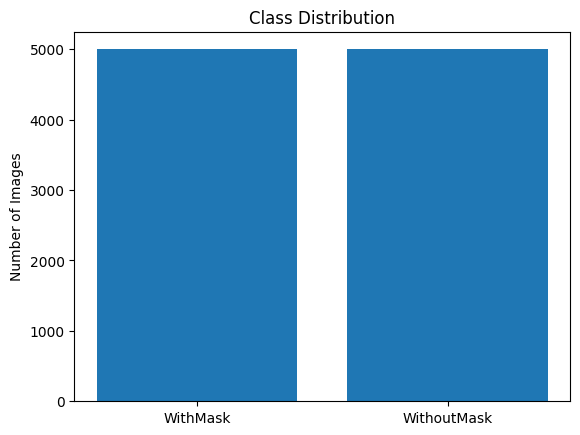

In [15]:
values = [counts[i] for i in range(len(class_names))]

plt.bar(class_names, values)
plt.title("Class Distribution")
plt.ylabel("Number of Images")
plt.show()

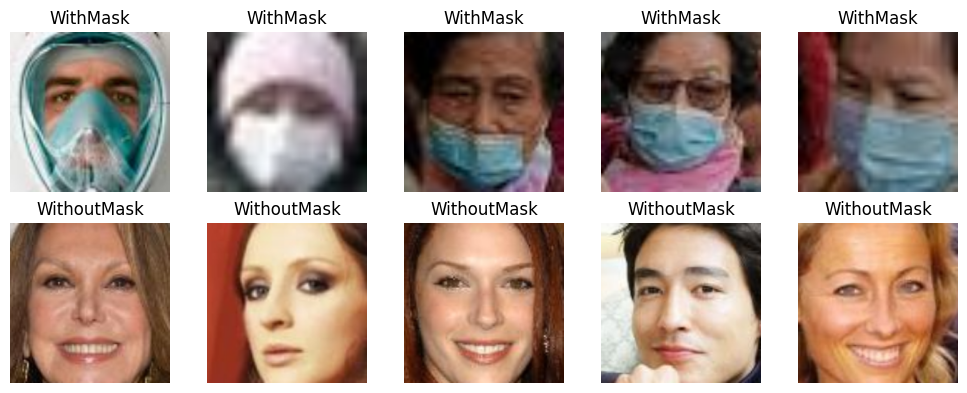

In [16]:
def show_samples(dataset, num_per_class=5):
    class_indices = {i: [] for i in range(len(dataset.classes))}

    for img, label in dataset:
        if len(class_indices[label]) < num_per_class:
            class_indices[label].append(img)

        if all(len(v) == num_per_class for v in class_indices.values()):
            break

    plt.figure(figsize=(10,4))

    plot_idx = 1
    for label, images in class_indices.items():
        for img in images:
            plt.subplot(len(dataset.classes), num_per_class, plot_idx)
            plt.imshow(img.permute(1,2,0))
            plt.title(dataset.classes[label])
            plt.axis("off")
            plot_idx += 1

    plt.tight_layout()
    plt.show()

show_samples(train_dataset)

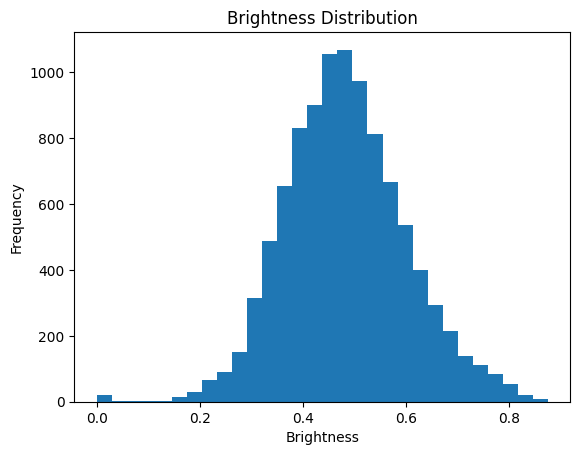

In [17]:
brightness_values = []

for img, _ in train_dataset:
    brightness_values.append(img.mean().item())

plt.hist(brightness_values, bins=30)
plt.title("Brightness Distribution")
plt.xlabel("Brightness")
plt.ylabel("Frequency")
plt.show()

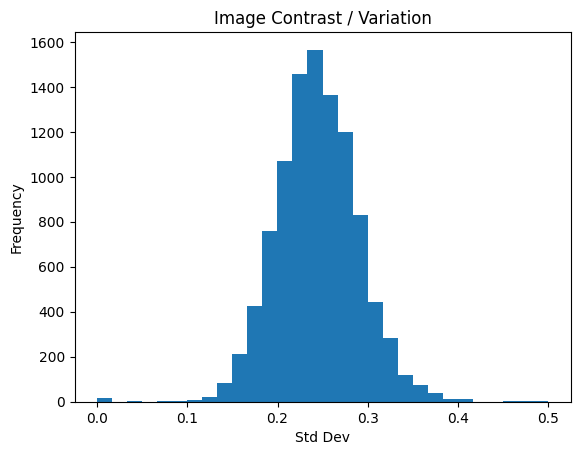

In [18]:
std_values = []

for img, _ in train_dataset:
    std_values.append(img.std().item())

plt.hist(std_values, bins=30)
plt.title("Image Contrast / Variation")
plt.xlabel("Std Dev")
plt.ylabel("Frequency")
plt.show()

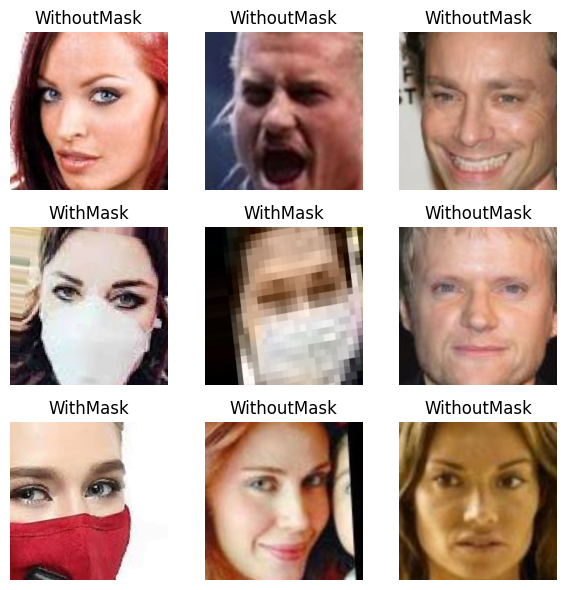

In [19]:
import random

def show_random_images(dataset, n=9):
    plt.figure(figsize=(6,6))

    for i in range(n):
        idx = random.randint(0, len(dataset)-1)
        img, label = dataset[idx]

        plt.subplot(3,3,i+1)
        plt.imshow(img.permute(1,2,0))
        plt.title(dataset.classes[label])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

show_random_images(train_dataset)

### Catastrophic Problem Detection

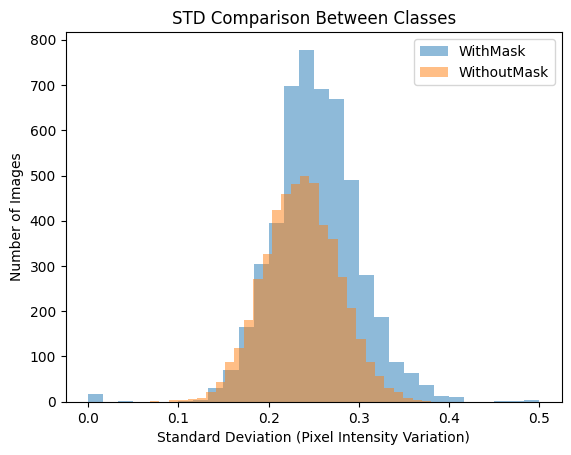

In [20]:
mask_std = []
no_mask_std = []

for img, label in train_dataset:
    if label == 0:  # WithMask
        mask_std.append(img.std().item())
    else:
        no_mask_std.append(img.std().item())

import matplotlib.pyplot as plt

plt.hist(mask_std, bins=30, alpha=0.5, label="WithMask")
plt.hist(no_mask_std, bins=30, alpha=0.5, label="WithoutMask")
plt.xlabel("Standard Deviation (Pixel Intensity Variation)")
plt.ylabel("Number of Images")
plt.title("STD Comparison Between Classes")
plt.legend()
plt.title("STD Comparison Between Classes")
plt.show()